# Undirected

In [ ]:
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

%load_ext autoreload
%autoreload 2
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt
from torch_geometric import utils
import sys

if '..' not in sys.path:
    sys.path.insert(0, '..')

from utils.plotting import plot_graph_with_omitted
import utils.link_prediction as lp


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:


data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 3, 5, 5],
                                     [5, 4, 5, 2, 5, 2, 4]]))

data.edge_attr = torch.tensor([1,1,1,1,1, 1,1]).bool()

data.edge_index, data.edge_attr = utils.to_undirected(data.edge_index, data.edge_attr)

#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)
#todo: make omit_dyads_random handle sampling rate of 0
dyads_to_omit_test = lp.omit_dyads_random(data.edge_index, 
                                data.edge_attr, 
                                p_sample_edge=0.0,
                                directed=False)
data_omitted1 = Data(edge_index=dyads_to_omit_test[2], edge_attr=dyads_to_omit_test[3])

print('omitted edges', dyads_to_omit_test[0])
print('omitted non edges', dyads_to_omit_test[1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)

#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.omit_dyads_random(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=0.0)
data_omitted2 = Data(edge_index=dyads_to_omit_val[2], edge_attr=dyads_to_omit_val[3])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST


NameError: name 'Data' is not defined

# Directed

In [4]:
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

%load_ext autoreload
%autoreload 2
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt
from torch_geometric import utils
import sys

if '..' not in sys.path:
    sys.path.insert(0, '..')

from utils.plotting import plot_graph_with_omitted
import utils.link_prediction as lp

import networkx as nx
import matplotlib.pyplot as plt
def plot_directed_graph(data):
    """
    Plot a directed graph from a PyG Data object.
    
    Args:
        data: PyG Data object containing edge_index
    """
    # Create directed graph
    G = nx.DiGraph()

    # Add nodes
    nodes = torch.unique(data.edge_index).tolist()
    G.add_nodes_from(nodes)

    # Add edges and track edge colors
    edges = list(zip(data.edge_index[0].tolist(), data.edge_index[1].tolist()))
    edge_colors = ['red' if attr else 'black' for attr in data.edge_attr.tolist()]
    G.add_edges_from(edges)

    # Draw graph
    plt.figure(figsize=(8,6))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            node_size=500, arrowsize=20, width=2,
            arrows=True, edge_color=edge_colors)
    plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


omitted edges (B) tensor([[0, 1],
        [4, 5]])
omitted non edges (C) tensor([[0, 1, 1, 2, 2, 3, 3, 4, 4, 5],
        [3, 3, 4, 3, 5, 1, 4, 0, 1, 3]])
new_edge_index tensor([[0, 3, 3, 5, 5, 0, 1, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5],
        [5, 2, 5, 2, 4, 4, 5, 3, 3, 4, 3, 5, 1, 4, 0, 1, 3]])
new_edge_attr tensor([ True,  True,  True,  True,  True, False, False, False, False, False,
        False, False, False, False, False, False, False])


/Users/danielzilberg/anaconda3/envs/pyg/lib/python3.10/site-packages/torch_geometric/data/storage.py:450: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_attr', 'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  warnings.warn(


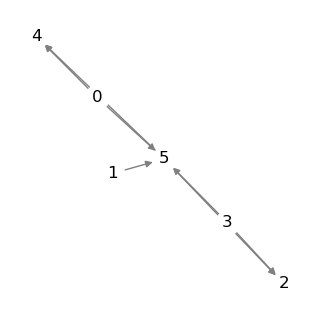

In [ ]:
data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 3, 5, 5],
                                     [5, 4, 5, 2, 5, 2, 4]]))

data.edge_attr = torch.tensor([1,1,1,1,1, 1,1]).bool()

#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)
test_p = 0.1
val_p = 0.1

#todo: test both get dyads to omit and omit dyads. 
dyads_to_omit_test = lp.omit_dyads_random(data.edge_index, 
                                data.edge_attr, 
                                p_sample_edge=0.1,
                                directed=True)
data_omitted1 = Data(edge_index=dyads_to_omit_test[1], edge_attr=dyads_to_omit_test[2])

# plot_directed_graph(data_omitted1)

print('omitted edges (B)', dyads_to_omit_test[0][0])
print('omitted non edges (C)', dyads_to_omit_test[0][1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)


#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.omit_dyads_random(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=val_p/(1-test_p), directed=True)
data_omitted2 = Data(edge_index=dyads_to_omit_val[1], edge_attr=dyads_to_omit_val[2])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST


# Undirected

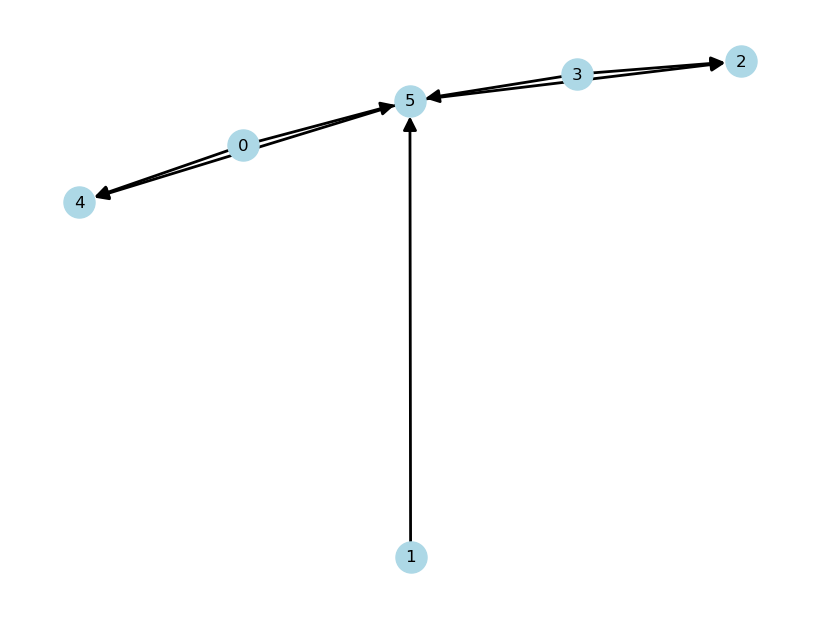

IndexError: tuple index out of range

In [ ]:
data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 3, 5, 5],
                                     [5, 4, 5, 2, 5, 2, 4]]))

data.edge_attr = torch.tensor([1,1,1,1,1, 1,1]).bool()
plot_directed_graph(data)
data.edge_index, data.edge_attr = utils.to_undirected(data.edge_index, data.edge_attr)

#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)


#todo: make omit_dyads_random handle sampling rate of 0
dyads_to_omit_test = lp.omit_dyads_random(data.edge_index, 
                                data.edge_attr, 
                                p_sample_edge=0.0,
                                directed=False)
data_omitted1 = Data(edge_index=dyads_to_omit_test[2], edge_attr=dyads_to_omit_test[3])

# plot_directed_graph(data_omitted1)

print('omitted edges', dyads_to_omit_test[0])
print('omitted non edges', dyads_to_omit_test[1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)

#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.omit_dyads_random(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=0.0)
data_omitted2 = Data(edge_index=dyads_to_omit_val[2], edge_attr=dyads_to_omit_val[3])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST
